In [15]:
import pandas as pd
import numpy as np
import os
import model.HS2SWE as swe_mod_slf

In [23]:
df = pd.read_csv("/Users/jakobwerkgarner/code/mt_dsnow/HS2SWE/data_prep/hs2swe_input/Adelboden.csv")
idata = np.transpose(np.array(df["hs"].values, ndmin=2))  # shape (T,1)

swe_sim = swe_mod_slf.HS2SWE(idata)

df['swe_mod'] = swe_sim

df

Running station: 1
Elapsed time for Station, 1 : 0.2719109058380127 s
Average time per station: 0.2722160816192627 s


,date,hs,swe_obs,swe_mod
0,2016-09-01,0.0,NaN,0.0
1,2016-09-02,0.0,NaN,0.0
2,2016-09-03,0.0,NaN,0.0
3,2016-09-04,0.0,NaN,0.0
4,2016-09-05,0.0,NaN,0.0
...,...,...,...,...
2186,2022-08-27,0.0,NaN,0.0
2187,2022-08-28,0.0,NaN,0.0
2188,2022-08-29,0.0,NaN,0.0
2189,2022-08-30,0.0,NaN,0.0


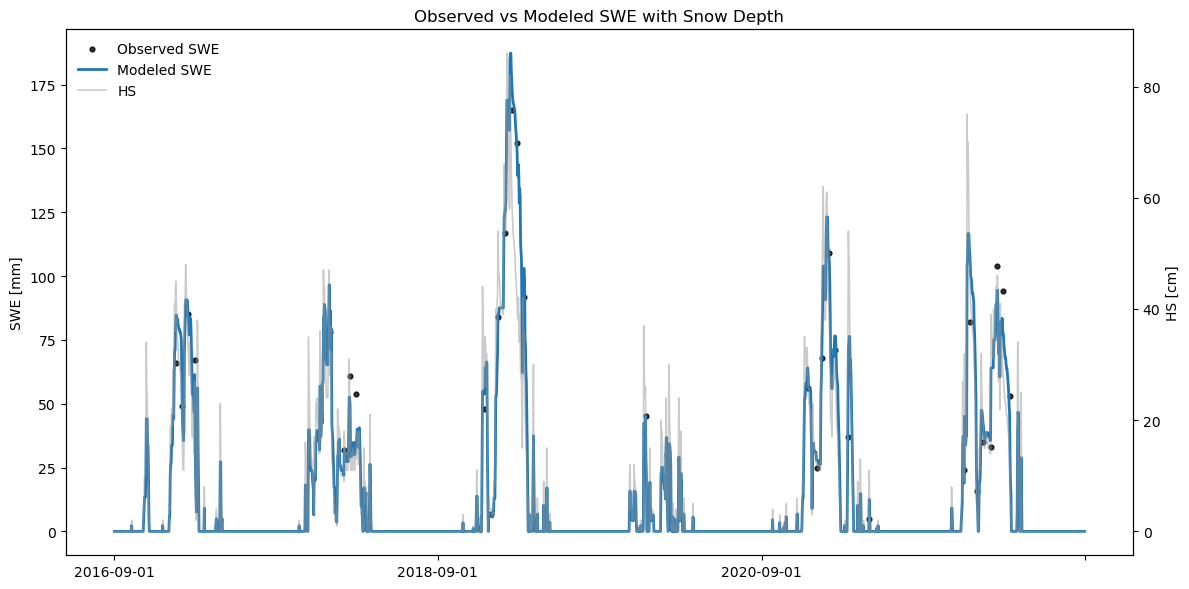

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12, 6))

x = df["date"]

# -----------------------------
# SWE: Observed (scatter)
# -----------------------------
ax1.scatter(
    x, df["swe_obs"],
    label="Observed SWE",
    color="black",
    s=12,
    alpha=0.8
)

# -----------------------------
# SWE: Modeled (line)
# -----------------------------
ax1.plot(
    x, df["swe_mod"],
    label="Modeled SWE",
    color="#1f77b4",    # muted blue
    linewidth=2
)

ax1.set_ylabel("SWE [mm]")
ax1.tick_params(axis="y")

# -----------------------------
# HS (secondary axis)
# -----------------------------
ax2 = ax1.twinx()

ax2.plot(
    x, df["hs"],
    label="HS",
    color="#999999",    # light grey for less dominance
    linewidth=1.2,
    alpha=0.5
)

ax2.set_ylabel("HS [cm]")
ax2.tick_params(axis="y")

# -----------------------------
# Modern x-axis formatting
# -----------------------------
ax1.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))

plt.setp(ax1.get_xticklabels(), rotation=0, ha="center")

# -----------------------------
# Title & Layout
# -----------------------------
plt.title("Observed vs Modeled SWE with Snow Depth")
fig.tight_layout()

# -----------------------------
# Combined Legend
# -----------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    frameon=False
)

plt.show()